# **1. Perkenalan Dataset**


### **Informasi Dataset**

- **Sumber Dataset**: [World Bank API - GDP Indonesia](https://api.worldbank.org/v2/country/IDN/indicator/NY.GDP.MKTP.CD?format=json&per_page=100)
- **Deskripsi Singkat**: Dataset ini berisi runtun waktu Produk Domestik Bruto (PDB) tahunan negara Indonesia (dalam USD) yang diakumulasikan dari tahun 1967 hingga 2024.
- **Karakteristik Data**: 
  - `Year` (integer): Tahun pencatatan.
  - `GDP_USD` (float): Nilai PDB Indonesia dalam USD pada tahun terkait.
  - `GDP_Growth_Rate` (float): Persentase pertumbuhan ekonomi tahunan yang dihitung dari persentase perubahan nilai PDB dari tahun sebelumnya.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [ ]:
# Mengambil data GDP Indonesia dari World Bank API dengan fallback lokal
import os
import requests
import pandas as pd

url = 'https://api.worldbank.org/v2/country/IDN/indicator/NY.GDP.MKTP.CD?format=json&per_page=100'
try:
    print("Mengambil data dari World Bank API...")
    response = requests.get(url, timeout=5)
    data = response.json()[1]
    df = pd.DataFrame(data)
    df = df[['date', 'value']].rename(columns={'date': 'Year', 'value': 'GDP_USD'})
    df['Year'] = df['Year'].astype(int)
    print("Berhasil mengambil data dari World Bank API!")
except Exception as e:
    print(f"API gagal diakses ({e}). Menggunakan fallback raw file lokal...")
    # Coba beberapa path relatif potensial
    raw_paths = [
        '../namadataset_raw/indonesia_gdp_raw.csv',
        'namadataset_raw/indonesia_gdp_raw.csv',
        'Eksperimen_SML_Cahyadi/namadataset_raw/indonesia_gdp_raw.csv'
    ]
    loaded = False
    for r_path in raw_paths:
        if os.path.exists(r_path):
            df = pd.read_csv(r_path)
            df = df[['Year', 'GDP_USD']]
            loaded = True
            print(f"Berhasil memuat raw file dari: {r_path}")
            break
    if not loaded:
        raise FileNotFoundError("Gagal menemukan file raw lokal untuk fallback.")

# Pembersihan data
df = df.dropna().sort_values('Year').reset_index(drop=True)

print("Dataset Ekonomi Indonesia (GDP) Berhasil Dimuat!")
display(df.tail())


Dataset Ekonomi Indonesia (GDP) Berhasil Dimuat!


,Year,GDP_USD
53,2020,1.059055e+12
54,2021,1.186510e+12
55,2022,1.319101e+12
56,2023,1.371169e+12
57,2024,1.396300e+12


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

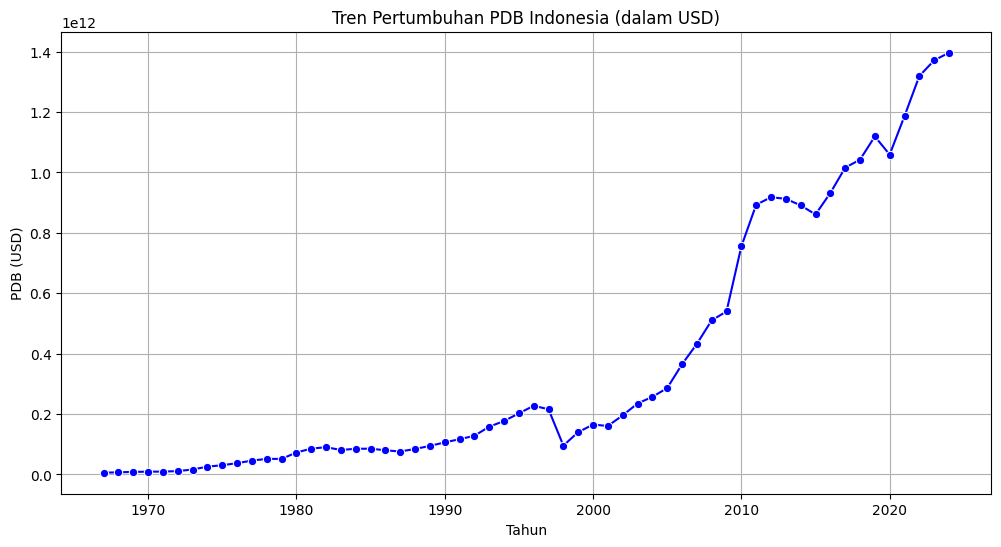

Statistik Deskriptif PDB Indonesia:


,Year,GDP_USD
count,58.000000,5.800000e+01
mean,1995.500000,3.711335e+11
std,16.886879,4.279248e+11
min,1967.000000,5.667757e+09
25%,1981.250000,7.693573e+10
50%,1995.500000,1.592268e+11
75%,2009.750000,7.012156e+11
max,2024.000000,1.396300e+12


In [ ]:
# Visualisasi Tren PDB Indonesia
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='Year', y='GDP_USD', marker='o', color='b')
plt.title('Tren Pertumbuhan PDB Indonesia (dalam USD)')
plt.xlabel('Tahun')
plt.ylabel('PDB (USD)')
plt.grid(True)
plt.show()

# Statistik Deskriptif
print("Statistik Deskriptif PDB Indonesia:")
display(df.describe())

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [ ]:
# Menghapus data duplikat
df = df.drop_duplicates()

# Menghitung pertumbuhan PDB tahunan (Percentage Change)
df['GDP_Growth_Rate'] = df['GDP_USD'].pct_change() * 100

# Menangani nilai NaN pada baris pertama akibat perhitungan pct_change
df['GDP_Growth_Rate'] = df['GDP_Growth_Rate'].fillna(0)

print("Data Preprocessing Selesai: Kolom 'GDP_Growth_Rate' telah ditambahkan.")
display(df.head())

# Mengecek apakah ada data yang kosong (Missing Values)
print("\nPengecekan Missing Values:")
print(df.isnull().sum())


Data Preprocessing Selesai: Kolom 'GDP_Growth_Rate' telah ditambahkan.


,Year,GDP_USD,GDP_Growth_Rate
0,1967,5.667757e+09,0.000000
1,1968,7.076465e+09,24.854784
2,1969,8.337423e+09,17.819038
3,1970,9.150685e+09,9.754352
4,1971,9.333536e+09,1.998227



Pengecekan Missing Values:
Year               0
GDP_USD            0
GDP_Growth_Rate    0
dtype: int64


In [ ]:
# Menyimpan hasil preprocessing ke csv
import os
os.makedirs('namadataset_preprocessing', exist_ok=True)
df.to_csv('namadataset_preprocessing/indonesia_gdp_preprocessed.csv', index=False)
print("Data preprocessed berhasil disimpan di namadataset_preprocessing/indonesia_gdp_preprocessed.csv")